# Physics-Informed DeepONet (PI-DeepONet)
### Nonlinear Steady-State Heat Conduction Solver

---

## 📋 Project Overview
This notebook implements a **Physics-Informed Neural Operator (DeepONet)** architecture designed to map parameter functions to solution fields. It learns to solve a 1D nonlinear steady-state thermal conduction boundary value problem in a **self-supervised manner**, relying entirely on physics-informed weak-form residuals rather than labeled training data ($Y_{\text{train}}$).

---

## 🔬 Mathematical Framework

### 1. Governing Differential Equation
The system balances internal thermal conduction across a domain $x \in [0, 1]$:

$$-\frac{d}{dx} \left( k(T, x) \frac{dT}{dx} \right) = 0$$

Where the thermal conductivity $k(T, x)$ is a nonlinear function dependent on both position and local temperature:

$$k(T, x) = \alpha(x) \left(0.5 + T^2\right)$$

### 2. Boundary Conditions
The system enforces non-homogeneous Dirichlet boundary conditions, structurally guaranteed inside the network architecture via an exact ansatz wrapper:

$$T(0) = 1.0, \quad T(1) = 0.0$$

---

## 🧠 Neural Operator Architecture

The **DeepONet** splits the problem into two cooperative subnetworks:
* **Branch Network:** Processes the discretized variable input function profile $\alpha(x)$ of shape `(N_NODES,)`.
* **Trunk Network:** Processes the continuous evaluation coordinate spatial location $x$ of shape `(1,)`.
* **Merging Layer:** Computes a dot-product between branch and trunk features ($P_{\text{modes}}$) to reconstruct the global state field.

---

## 🛠️ Tech Stack & Optimization
* **Computing Engine:** `JAX` (Utilizes XLA Just-In-Time compilation and `vmap` vectorization)
* **Optimization Framework:** `Optax` (AdamW optimizer paired with a Cosine Decay learning rate schedule)
* **Physics Loss Evaluator:** Finite Element Method (`FEM`) algebraic weak-form residual matching

In [1]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURATION
# ==========================================
N_GRID = 64
N_NODES = N_GRID + 1
P_MODES = 32      # Number of trunk-branch trunk merging features (p)
WIDTH = 64        # Network hidden layer width
BATCH_SIZE = 32
EPOCHS = 10001      
N_SAMPLES = 1000 
TRAIN_SAMPLES = 800
VAL_SAMPLES = 100  
GRID = jnp.linspace(0, 1, N_NODES)

# ==========================================
# 2. PHYSICS & STEADY-STATE RESIDUALS
# ==========================================
@jax.jit
def generate_smooth_fn(key):
    x = jnp.linspace(0, 1, N_NODES)
    k1, k2 = jax.random.split(key, 2)
    freqs = jax.random.uniform(k1, (3,), minval=1.0, maxval=3.0)
    amps = jax.random.uniform(k2, (3,), minval=0.1, maxval=0.3)
    return jnp.sum(amps[:, None] * jnp.sin(freqs[:, None] * jnp.pi * x), axis=0)

@jax.jit
def solve_steady_fem(alpha_x):
    """
    Solves the nonlinear steady state FEM problem: -d/dx( k(T) dT/dx ) = 0
    via a simple Picard iteration for data generation.
    """
    dx = 1.0 / N_GRID
    free = jnp.arange(1, N_NODES - 1)
    
    def picard_step(T_curr, _):
        K_mat = jnp.zeros((N_NODES, N_NODES))
        k_nodal = alpha_x * (0.5 + T_curr**2)
        for e in range(N_GRID):
            ix = jnp.array([e, e + 1])
            k_avg = 0.5 * (k_nodal[e] + k_nodal[e+1])
            ke = (k_avg / dx) * jnp.array([[1.0, -1.0], [-1.0, 1.0]])
            K_mat = K_mat.at[jnp.ix_(ix, ix)].add(ke)
            
        RHS_free = - K_mat[free, 0] * 1.0 - K_mat[free, -1] * 0.0
        T_next_free = jnp.linalg.solve(K_mat[jnp.ix_(free, free)], RHS_free)
        T_next = jnp.zeros(N_NODES).at[0].set(1.0).at[-1].set(0.0).at[free].set(T_next_free)
        return T_next, None

    T_init = jnp.linspace(1.0, 0.0, N_NODES)
    T_final, _ = jax.lax.scan(picard_step, T_init, None, length=15)
    return T_final

@jax.jit
def compute_steady_weak_residual(T_pred, alpha_x):
    """
    Evaluates the steady state algebraic weak form residual (K(T) * T)
    on internal nodes.
    """
    dx = 1.0 / N_GRID
    K_mat = jnp.zeros((N_NODES, N_NODES))
    
    k_nodal = alpha_x * (0.5 + T_pred**2)
    for e in range(N_GRID):
        ix = jnp.array([e, e + 1])
        k_avg = 0.5 * (k_nodal[e] + k_nodal[e+1])
        ke = (k_avg / dx) * jnp.array([[1.0, -1.0], [-1.0, 1.0]])
        K_mat = K_mat.at[jnp.ix_(ix, ix)].add(ke)
        
    residual = K_mat @ T_pred
    free = jnp.arange(1, N_NODES - 1)
    return residual[free]

@jax.jit
def generate_data_point(key_k):
    alpha = jax.nn.sigmoid(generate_smooth_fn(key_k)) * 0.4 + 0.1
    T_steady = solve_steady_fem(alpha)
    return alpha, T_steady

# ==========================================
# 3. DEEPONET ARCHITECTURE
# ==========================================
def mlp(x, weights):
    # Standard MLP helper for branch and trunk components
    for w, b in weights[:-1]:
        x = jax.nn.gelu(jnp.dot(x, w) + b)
    out_w, out_b = weights[-1]
    return jnp.dot(x, out_w) + out_b

def deeponet_model(params, alpha_profile, x_coord):
    """
    Evaluates DeepONet for a single sample at a specific coordinate x_coord.
    alpha_profile: shape (N_NODES,) -> Branch Input
    x_coord: shape (1,) -> Trunk Input
    """
    branch_params, trunk_params, bias = params
    
    # 1. Branch Net: input is the discretized function alpha
    branch_out = mlp(alpha_profile, branch_params) # Output size: P_MODES
    
    # 2. Trunk Net: input is the evaluation coordinate x
    trunk_out = mlp(x_coord, trunk_params)         # Output size: P_MODES
    
    # 3. Merge via dot product + hardcoded boundary constraints (mask)
    res = jnp.dot(branch_out, trunk_out) + bias
    
    # Enforce boundary conditions: T(0)=1, T(1)=0
    # Using a structural ansatz: T(x) = (1 - x) + x * (1 - x) * Network(x)
    x = x_coord[0]
    return (1.0 - x) + x * (1.0 - x) * res

def init_mlp_params(key, layers):
    keys = jax.random.split(key, len(layers))
    params = []
    for i in range(len(layers) - 1):
        in_dim, out_dim = layers[i], layers[i+1]
        w_key, b_key = jax.random.split(keys[i])
        w = jax.random.normal(w_key, (in_dim, out_dim)) * jnp.sqrt(2.0 / in_dim)
        b = jnp.zeros(out_dim)
        params.append((w, b))
    return params

def init_deeponet_params(key):
    k1, k2, k3 = jax.random.split(key, 3)
    branch_layers = [N_NODES, WIDTH, WIDTH, P_MODES]
    trunk_layers = [1, WIDTH, WIDTH, P_MODES]
    
    branch_params = init_mlp_params(k1, branch_layers)
    trunk_params = init_mlp_params(k2, trunk_layers)
    bias = jax.random.normal(k3, ()) * 0.01
    return (branch_params, trunk_params, bias)

# ==========================================
# 4. DATA PIPELINE PREPARATION
# ==========================================
print("Generating Underlying Steady-State Synthetic Space...")
keys_k = jax.random.split(jax.random.PRNGKey(42), N_SAMPLES)
all_Alpha, all_T_steady = jax.vmap(generate_data_point)(keys_k)

# Split datasets
alpha_train = all_Alpha[:TRAIN_SAMPLES]
alpha_val = all_Alpha[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]
Y_val = all_T_steady[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]

# Standardize branch inputs (alpha profiles)
alpha_mean, alpha_std = alpha_train.mean(), alpha_train.std() + 1e-7
alpha_train_norm = (alpha_train - alpha_mean) / alpha_std
alpha_val_norm = (alpha_val - alpha_mean) / alpha_std

# For DeepONet physics evaluation, we require full field evaluations
# We create an explicit grid array of shape (N_NODES, 1) for the trunk
Trunk_Grid = GRID[:, None]

# ==========================================
# 5. PHYSICS-INFORMED LOSS & OPTIMIZATION
# ==========================================
params = init_deeponet_params(jax.random.PRNGKey(123))
lr_schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=EPOCHS, alpha=1e-2)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)
opt_state = optimizer.init(params)

@jax.jit
def predict_full_field(p, alpha_norm_profile):
    # Vectorize model evaluations across the spatial grid coordinates for one sample
    return jax.vmap(deeponet_model, (None, None, 0))(p, alpha_norm_profile, Trunk_Grid)

@jax.jit
def train_step(p, opt_s, b_alpha_norm, b_alpha_raw):
    def loss_fn(p):
        # 1. Predict full steady state profile for entire batch
        T_preds = jax.vmap(predict_full_field, (None, 0))(p, b_alpha_norm)
        # 2. Evaluate steady state physical residual discrepancies
        residuals = jax.vmap(compute_steady_weak_residual, (0, 0))(T_preds, b_alpha_raw)
        return jnp.mean(residuals**2)
        
    l, g = jax.value_and_grad(loss_fn)(p)
    u, opt_s = optimizer.update(g, opt_s, p)
    return optax.apply_updates(p, u), opt_s, l

@jax.jit
def evaluate_validation_loss(p, b_alpha_norm, b_Y):
    preds = jax.vmap(predict_full_field, (None, 0))(p, b_alpha_norm)
    return jnp.mean((preds - b_Y)**2)

loss_history, val_history = [], []

print(f"Training for {EPOCHS} epochs using self-supervised DeepONet Steady-Form residuals...")
for i in range(EPOCHS):
    idx = jax.random.randint(jax.random.PRNGKey(i), (BATCH_SIZE,), 0, alpha_train.shape[0])
    
    # Execute step without passing target labels (Y)
    params, opt_state, loss = train_step(params, opt_state, alpha_train_norm[idx], alpha_train[idx])
    
    if i % 100 == 0:
        val_loss = evaluate_validation_loss(params, alpha_val_norm, Y_val)
        loss_history.append(float(loss))
        val_history.append(float(val_loss))
        
    if i % 1000 == 0: 
        print(f"Epoch {i:4d} | Physics Residual MSE: {loss:.6e} | Val Data Mismatch MSE: {val_loss:.6e}")

# ==========================================
# 6. STEADY STATE EVALUATION
# ==========================================
test_idx = TRAIN_SAMPLES + VAL_SAMPLES + 5
alpha_test = all_Alpha[test_idx]
true_steady = all_T_steady[test_idx]

alpha_test_norm = (alpha_test - alpha_mean) / alpha_std
deeponet_steady = predict_full_field(params, alpha_test_norm)
abs_error = jnp.abs(true_steady - deeponet_steady)

print("\nEvaluation Complete.")
print(f"Max Absolute Error on Unseen Test Configuration: {jnp.max(abs_error):.4e}")

Generating Underlying Steady-State Synthetic Space...
Training for 10001 epochs using self-supervised DeepONet Steady-Form residuals...
Epoch    0 | Physics Residual MSE: 8.502720e-02 | Val Data Mismatch MSE: 4.845009e-01
Epoch 1000 | Physics Residual MSE: 4.857686e-06 | Val Data Mismatch MSE: 7.825267e-04
Epoch 2000 | Physics Residual MSE: 1.341206e-06 | Val Data Mismatch MSE: 3.790632e-04
Epoch 3000 | Physics Residual MSE: 7.521628e-07 | Val Data Mismatch MSE: 1.154971e-04
Epoch 4000 | Physics Residual MSE: 4.312829e-07 | Val Data Mismatch MSE: 5.866913e-05
Epoch 5000 | Physics Residual MSE: 2.439177e-07 | Val Data Mismatch MSE: 3.716806e-05
Epoch 6000 | Physics Residual MSE: 2.824288e-07 | Val Data Mismatch MSE: 3.225930e-05
Epoch 7000 | Physics Residual MSE: 1.397724e-07 | Val Data Mismatch MSE: 2.440959e-05
Epoch 8000 | Physics Residual MSE: 2.393231e-07 | Val Data Mismatch MSE: 2.005857e-05
Epoch 9000 | Physics Residual MSE: 2.091046e-07 | Val Data Mismatch MSE: 2.138998e-05
Epoc

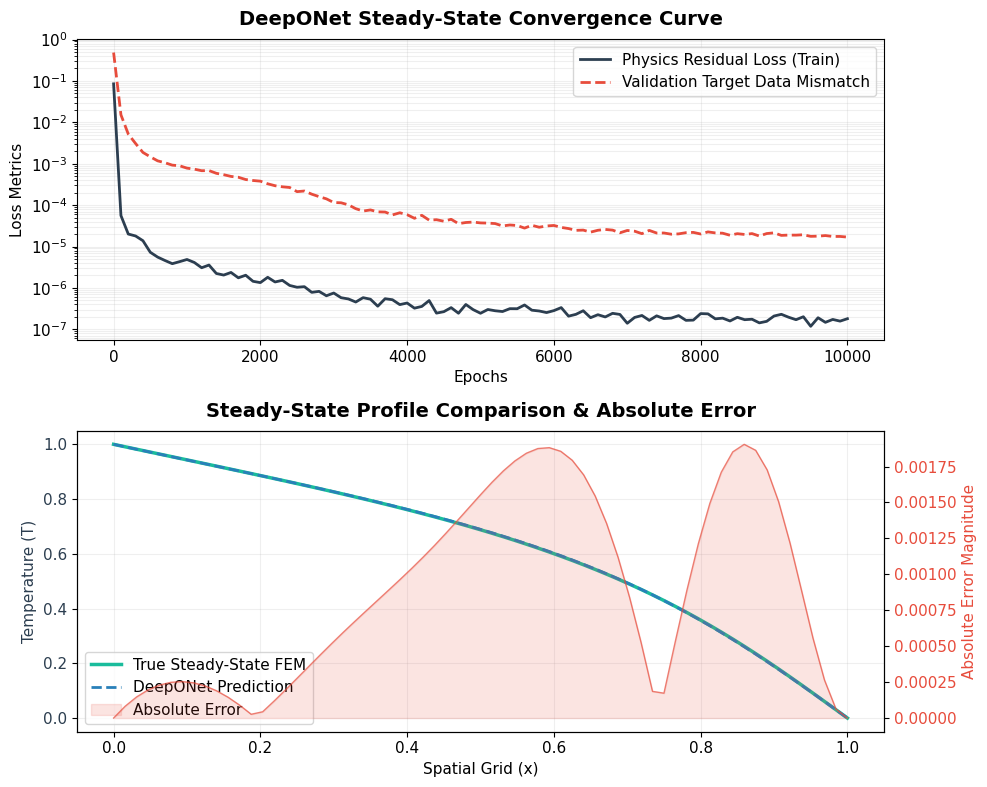

In [2]:
# ==========================================
# 7. POST-PROCESSING VISUALIZATION
# ==========================================
plt.rcParams.update({'font.size': 11})
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 8))

# --- Plot 0: Convergence Curve ---
# Recompute evaluation metrics on the correct interval matching your logging
epochs_recorded = np.arange(0, EPOCHS, 100)

ax0.plot(epochs_recorded, loss_history, color='#2c3e50', lw=2, label='Physics Residual Loss (Train)')
ax0.plot(epochs_recorded, val_history, color='#e74c3c', lw=2, ls='--', label='Validation Target Data Mismatch')
ax0.set_yscale('log')
ax0.set_title("DeepONet Steady-State Convergence Curve", fontweight='bold', fontsize=14, pad=10)
ax0.set_xlabel("Epochs")
ax0.set_ylabel("Loss Metrics")
ax0.grid(True, which="both", ls="-", alpha=0.2)
ax0.legend(loc='upper right')

# --- Plot 1: Profile Comparison and Absolute Error ---
# Primary y-axis for T(x) profiles
color_true = '#1abc9c'
color_pred = '#2980b9'

ax1.plot(GRID, true_steady, color=color_true, lw=2.5, label='True Steady-State FEM')
ax1.plot(GRID, deeponet_steady, color=color_pred, lw=2, ls='--', label='DeepONet Prediction')
ax1.set_title("Steady-State Profile Comparison & Absolute Error", fontweight='bold', fontsize=14, pad=10)
ax1.set_xlabel("Spatial Grid (x)")
ax1.set_ylabel("Temperature (T)", color='#2c3e50')
ax1.tick_params(axis='y', labelcolor='#2c3e50')
ax1.grid(True, alpha=0.2)

# Secondary y-axis for Absolute Error
ax1_twin = ax1.twinx()
ax1_twin.fill_between(GRID, abs_error, color='#e74c3c', alpha=0.15, label='Absolute Error')
ax1_twin.plot(GRID, abs_error, color='#e74c3c', lw=1, alpha=0.7)
ax1_twin.set_ylabel("Absolute Error Magnitude", color='#e74c3c')
ax1_twin.tick_params(axis='y', labelcolor='#e74c3c')

# Combine legends from split y-axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.show()

# Physics-Informed Fourier Neural Operator (PI-FNO)
### Nonlinear Steady-State Heat Conduction Solver

---

## 📋 Project Overview & Mathematical Framework
The core problem, governing differential equations, boundary conditions, and self-supervised training paradigm are **identical** to the DeepONet implementation. The system still solves the 1D nonlinear thermal conduction problem using entirely physics-informed weak-form residuals without labeled data. 

The only fundamental difference lies in the **network architecture** used to learn the operator mapping.

---

## 🧠 Neural Operator Architecture (The Main Difference)

While DeepONet uncouples functions and coordinates via distinct Branch and Trunk networks, the **Fourier Neural Operator (FNO)** processes the continuous input function globally by parameterizing the integral kernel directly in the frequency domain:

* **Lifting Layer:** Projects the raw spatial features $[\alpha(x), x]$ into a higher-dimensional latent tensor across the grid.
* **Spectral Layers:** Converts features into frequency space via a Fast Fourier Transform (FFT), filters out high frequencies to retain only the lower structural modes ($N_{\text{modes}}$), applies learnable complex weight multiplications, and returns to the physical domain using an Inverse FFT (IFFT).
* **Residual/Projection Layers:** Fuses the global frequency updates with local spatial skip connections through GELU activations, projecting the latent features down to the final target 1D temperature field.

---

## 🛠️ Tech Stack & Optimization
* **Computing Engine:** `JAX` (Utilizes XLA Just-In-Time compilation and `vmap` vectorization)
* **Optimization Framework:** `Optax` (AdamW optimizer paired with a Cosine Decay learning rate schedule)
* **Physics Loss Evaluator:** Finite Element Method (`FEM`) algebraic weak-form residual matching

Generating Underlying Steady-State Synthetic Space...
Training for 10001 epochs using self-supervised FNO Steady-Form residuals...
Epoch    0 | Physics Residual MSE: 3.855290e-05 | Val Data Mismatch MSE: 1.579278e-02
Epoch 1000 | Physics Residual MSE: 2.781087e-06 | Val Data Mismatch MSE: 4.857552e-04
Epoch 2000 | Physics Residual MSE: 2.703026e-06 | Val Data Mismatch MSE: 3.959424e-04
Epoch 3000 | Physics Residual MSE: 8.303999e-07 | Val Data Mismatch MSE: 1.052123e-04
Epoch 4000 | Physics Residual MSE: 7.558230e-07 | Val Data Mismatch MSE: 1.132989e-04
Epoch 5000 | Physics Residual MSE: 4.078163e-07 | Val Data Mismatch MSE: 8.464116e-05
Epoch 6000 | Physics Residual MSE: 3.326008e-07 | Val Data Mismatch MSE: 5.383652e-05
Epoch 7000 | Physics Residual MSE: 1.955004e-07 | Val Data Mismatch MSE: 3.693221e-05
Epoch 8000 | Physics Residual MSE: 2.400499e-07 | Val Data Mismatch MSE: 3.030746e-05
Epoch 9000 | Physics Residual MSE: 1.726476e-07 | Val Data Mismatch MSE: 2.536424e-05
Epoch 100

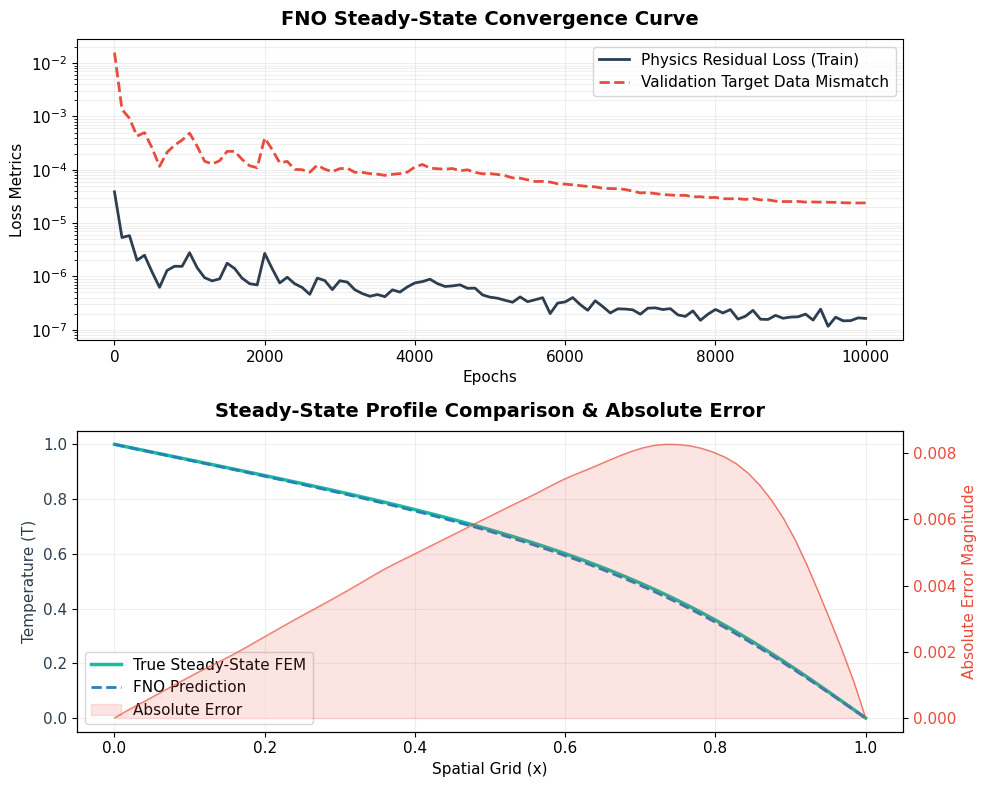

In [5]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURATION
# ==========================================
N_GRID = 64
N_NODES = N_GRID + 1
WIDTH = 64
MODES = 8        
BATCH_SIZE = 32
EPOCHS = 10001      
N_SAMPLES = 1000 
TRAIN_SAMPLES = 800
VAL_SAMPLES = 100  
GRID = jnp.linspace(0, 1, N_NODES)

# ==========================================
# 2. PHYSICS & STEADY-STATE RESIDUALS
# ==========================================
@jax.jit
def generate_smooth_fn(key):
    x = jnp.linspace(0, 1, N_NODES)
    k1, k2 = jax.random.split(key, 2)
    freqs = jax.random.uniform(k1, (3,), minval=1.0, maxval=3.0)
    amps = jax.random.uniform(k2, (3,), minval=0.1, maxval=0.3)
    return jnp.sum(amps[:, None] * jnp.sin(freqs[:, None] * jnp.pi * x), axis=0)

@jax.jit
def solve_steady_fem(alpha_x):
    """
    Solves the nonlinear steady state FEM problem: -d/dx( k(T) dT/dx ) = 0
    via a simple Picard iteration for generating validation target data.
    """
    dx = 1.0 / N_GRID
    free = jnp.arange(1, N_NODES - 1)
    
    def picard_step(T_curr, _):
        K_mat = jnp.zeros((N_NODES, N_NODES))
        k_nodal = alpha_x * (0.5 + T_curr**2)
        for e in range(N_GRID):
            ix = jnp.array([e, e + 1])
            k_avg = 0.5 * (k_nodal[e] + k_nodal[e+1])
            ke = (k_avg / dx) * jnp.array([[1.0, -1.0], [-1.0, 1.0]])
            K_mat = K_mat.at[jnp.ix_(ix, ix)].add(ke)
            
        RHS_free = - K_mat[free, 0] * 1.0 - K_mat[free, -1] * 0.0
        T_next_free = jnp.linalg.solve(K_mat[jnp.ix_(free, free)], RHS_free)
        T_next = jnp.zeros(N_NODES).at[0].set(1.0).at[-1].set(0.0).at[free].set(T_next_free)
        return T_next, None

    T_init = jnp.linspace(1.0, 0.0, N_NODES)
    T_final, _ = jax.lax.scan(picard_step, T_init, None, length=15)
    return T_final

@jax.jit
def compute_steady_weak_residual(T_pred, alpha_x):
    """
    Evaluates the steady state algebraic weak form residual (K(T) * T)
    on internal nodes based on the physical state.
    """
    dx = 1.0 / N_GRID
    K_mat = jnp.zeros((N_NODES, N_NODES))
    
    k_nodal = alpha_x * (0.5 + T_pred**2)
    for e in range(N_GRID):
        ix = jnp.array([e, e + 1])
        k_avg = 0.5 * (k_nodal[e] + k_nodal[e+1])
        ke = (k_avg / dx) * jnp.array([[1.0, -1.0], [-1.0, 1.0]])
        K_mat = K_mat.at[jnp.ix_(ix, ix)].add(ke)
        
    residual = K_mat @ T_pred
    free = jnp.arange(1, N_NODES - 1)
    return residual[free]

@jax.jit
def generate_data_point(key_k):
    alpha = jax.nn.sigmoid(generate_smooth_fn(key_k)) * 0.4 + 0.1
    T_steady = solve_steady_fem(alpha)
    return alpha, T_steady

# ==========================================
# 3. FOURIER NEURAL OPERATOR (MODEL)
# ==========================================
def spectral_layer(x, w_spec, w_skip):
    n = x.shape[0]
    x_ft = jnp.fft.rfft(x, axis=0)
    out_ft = jnp.zeros_like(x_ft, dtype=jnp.complex64).at[:MODES].set(
        jnp.einsum('mi, mij -> mj', x_ft[:MODES], w_spec))
    return jax.nn.gelu(jnp.fft.irfft(out_ft, n=n, axis=0) + jnp.dot(x, w_skip))

def fno_model(params, x_norm):
    """
    Predicts the full steady state field directly from input function profiles.
    Input features: [alpha(x), x]
    """
    x = jax.nn.gelu(jnp.dot(x_norm, params[0]) + params[1])
    for i in range(2, 10, 2):
        x = spectral_layer(x, params[i], params[i+1])
    x = jax.nn.gelu(jnp.dot(x, params[10]) + params[11])
    res = (jnp.dot(x, params[12]) + params[13]).squeeze()
    
    # Boundary condition matching ansatz for steady state: T(0) = 1, T(1) = 0
    return (1.0 - GRID) + GRID * (1.0 - GRID) * res

def init_params(key):
    keys = jax.random.split(key, 12)
    def norm_init(k, s): return jax.random.normal(k, s) * jnp.sqrt(1.0 / s[-1])
    p = [norm_init(keys[0], (2, WIDTH)), jnp.zeros(WIDTH)]
    for i in range(4):
        p.append(jax.random.normal(keys[i+1], (MODES, WIDTH, WIDTH), dtype=jnp.complex64) * 0.02)
        p.append(norm_init(keys[i+5], (WIDTH, WIDTH)))
    p.extend([norm_init(keys[10], (WIDTH, WIDTH)), jnp.zeros(WIDTH), 
              norm_init(keys[11], (WIDTH, 1)), jnp.zeros(1)])
    return p

# ==========================================
# 4. DATA PIPELINE PREPARATION
# ==========================================
print("Generating Underlying Steady-State Synthetic Space...")
keys_k = jax.random.split(jax.random.PRNGKey(42), N_SAMPLES)
all_Alpha, all_T_steady = jax.vmap(generate_data_point)(keys_k)

grid_expanded = jnp.tile(GRID[:, None], (N_SAMPLES, 1, 1))
X_raw = jnp.stack([all_Alpha, grid_expanded.squeeze(-1)], axis=-1)

X_train_flat = X_raw[:TRAIN_SAMPLES]
X_val_flat = X_raw[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]
Y_val_flat = all_T_steady[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]

x_mean, x_std = X_train_flat.mean(axis=(0, 1)), X_train_flat.std(axis=(0, 1)) + 1e-7
X_train_norm = (X_train_flat - x_mean) / x_std
X_val_norm = (X_val_flat - x_mean) / x_std

# ==========================================
# 5. PHYSICS-INFORMED LOSS & OPTIMIZATION
# ==========================================
params = init_params(jax.random.PRNGKey(123))
lr_schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=EPOCHS, alpha=1e-2)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)
opt_state = optimizer.init(params)

@jax.jit
def train_step(p, opt_s, b_X_norm, b_X_raw):
    alpha_batch = b_X_raw[:, :, 0]
    
    def loss_fn(p):
        T_preds = jax.vmap(fno_model, (None, 0))(p, b_X_norm)
        residuals = jax.vmap(compute_steady_weak_residual, (0, 0))(T_preds, alpha_batch)
        return jnp.mean(residuals**2)
        
    l, g = jax.value_and_grad(loss_fn)(p)
    u, opt_s = optimizer.update(g, opt_s, p)
    return optax.apply_updates(p, u), opt_s, l

@jax.jit
def evaluate_validation_loss(p, b_X_norm, b_Y):
    preds = jax.vmap(fno_model, (None, 0))(p, b_X_norm)
    return jnp.mean((preds - b_Y)**2)

loss_history, val_history = [], []

print(f"Training for {EPOCHS} epochs using self-supervised FNO Steady-Form residuals...")
for i in range(EPOCHS):
    idx = jax.random.randint(jax.random.PRNGKey(i), (BATCH_SIZE,), 0, X_train_flat.shape[0])
    params, opt_state, loss = train_step(params, opt_state, X_train_norm[idx], X_train_flat[idx])
    
    if i % 100 == 0:
        val_loss = evaluate_validation_loss(params, X_val_norm, Y_val_flat)
        loss_history.append(float(loss))
        val_history.append(float(val_loss))
        
    if i % 1000 == 0: 
        print(f"Epoch {i:4d} | Physics Residual MSE: {loss:.6e} | Val Data Mismatch MSE: {val_loss:.6e}")

# ==========================================
# 6. STEADY STATE EVALUATION
# ==========================================
test_idx = TRAIN_SAMPLES + VAL_SAMPLES + 5
alpha_test = all_Alpha[test_idx]
true_steady = all_T_steady[test_idx]

X_test_raw = jnp.stack([alpha_test, GRID], axis=-1)
X_test_norm = (X_test_raw - x_mean) / x_std

fno_steady = fno_model(params, X_test_norm)
abs_error = jnp.abs(true_steady - fno_steady)

print("\nEvaluation Complete.")
print(f"Max Absolute Error on Unseen Test Configuration: {jnp.max(abs_error):.4e}")

# ==========================================
# 7. POST-PROCESSING VISUALIZATION
# ==========================================
plt.rcParams.update({'font.size': 11})
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 8))

epochs_recorded = np.arange(0, EPOCHS, 100)
ax0.plot(epochs_recorded, loss_history, color='#2c3e50', lw=2, label='Physics Residual Loss (Train)')
ax0.plot(epochs_recorded, val_history, color='#e74c3c', lw=2, ls='--', label='Validation Target Data Mismatch')
ax0.set_yscale('log')
ax0.set_title("FNO Steady-State Convergence Curve", fontweight='bold', fontsize=14, pad=10)
ax0.set_xlabel("Epochs")
ax0.set_ylabel("Loss Metrics")
ax0.grid(True, which="both", ls="-", alpha=0.2)
ax0.legend(loc='upper right')

color_true = '#1abc9c'
color_pred = '#2980b9'

ax1.plot(GRID, true_steady, color=color_true, lw=2.5, label='True Steady-State FEM')
ax1.plot(GRID, fno_steady, color=color_pred, lw=2, ls='--', label='FNO Prediction')
ax1.set_title("Steady-State Profile Comparison & Absolute Error", fontweight='bold', fontsize=14, pad=10)
ax1.set_xlabel("Spatial Grid (x)")
ax1.set_ylabel("Temperature (T)", color='#2c3e50')
ax1.tick_params(axis='y', labelcolor='#2c3e50')
ax1.grid(True, alpha=0.2)

ax1_twin = ax1.twinx()
ax1_twin.fill_between(GRID, abs_error, color='#e74c3c', alpha=0.15, label='Absolute Error')
ax1_twin.plot(GRID, abs_error, color='#e74c3c', lw=1, alpha=0.7)
ax1_twin.set_ylabel("Absolute Error Magnitude", color='#e74c3c')
ax1_twin.tick_params(axis='y', labelcolor='#e74c3c')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.show()

# Physics-Informed Operator Benchmarking Framework
### FNO vs. DeepONet Under Strong Residual & Energy Loss Formulations (ID vs. OOD Performance)

---

## 📋 Project Overview
This notebook implements a comprehensive benchmarking suite to evaluate and compare two state-of-the-art neural operator paradigms—**Fourier Neural Operators (FNO)** and **Deep Operator Networks (DeepONet)**. 

Both architectures are trained to solve a 1D non-linear steady-state heat conduction problem in a completely **self-supervised (physics-informed)** manner. The framework evaluates performance across two axes:
1. **Loss Formulations:** Comparing standard algebraic **Strong-Form Residuals** against a physical **Corrected Energy Formulation**.
2. **Generalization Capabilities:** Testing models on standard In-Distribution (ID) profiles and Out-of-Distribution (OOD) geometric stress-tests (step functions, pyramids, and high-frequency sine waves).

---

## 🔬 Physics Objectives & Loss Formulations

The networks map the input conductive parameter function $\alpha(x)$ to the output temperature field $T(x)$. Training optimizes the network parameters using one of two distinct physical formulations without any labeled training pairs ($Y_{\text{train}}$):

### 1. Strong-Form Residual Norm (`loss_residual_norm`)
Evaluates the standard algebraic weak-form residual vectors across internal grid nodes using the localized finite element stiffness matrix $K(T)$:
$$\mathcal{L}_{\text{Residual}} = \frac{1}{N_{\text{free}}} \sum_{i \in \text{free}} \left| [K(T)T]_i \right|^2$$

### 2. Energy Minimization/Field Form (`loss_energy_form`)
Evaluates local energy bounds by taking the element-wise inner product of the unconstrained homogeneous temperature field ($T_0$, where boundaries are zeroed out) and the physical residual flux:
$$\mathcal{L}_{\text{Energy}} = \frac{1}{N_{\text{free}}} \sum_{i \in \text{free}} \left| T_{0, i} \cdot [K(T)T]_i \right|^2$$

---

## 🧠 Model Architectures Evaluated

| Model Topology | Input Handling Mechanism | Spatial Processing Paradigm |
| :--- | :--- | :--- |
| **Fourier Neural Operator (FNO)** | Accepts the raw global discretization mesh simultaneously: $[\alpha(x), x]$. | Processes global functions by performing parameter learnable kernel convolutions directly within the **frequency domain** via standard FFTs/IFFTs. |
| **Deep Operator Network (DeepONet)** | Completely uncouples function space from the evaluation grid via two sub-networks. | A **Branch Net** maps the structural sensor values of $\alpha(x)$ while a **Trunk Net** maps coordinate space $x$. Merged via a late fusion dot-product. |

*Note: Both models enforce non-homogeneous Dirichlet boundary conditions ($T(0)=1, T(1)=0$) explicitly via a hard-coded exact mathematical ansatz.*

---

## 🚀 Pipeline Workflow

1. **In-Distribution (ID) Synthesis:** Generates smooth, overlapping sinusoidal representations of $\alpha(x)$ paired with traditional Picard-FEM steady-state numeric answers for validation tracking.
2. **Out-of-Distribution (OOD) Stress-Testing:** Creates challenging geometric profiles for $\alpha(x)$ that the operators never see during training:
   * **Step functions:** Discontinuous material transitions.
   * **Pyramids:** Linear localized gradients with sharp peaks.
   * **Sharp Sines:** High-frequency variations testing spatial resolution limits.
3. **Parallel Training Loop (`run_training_loop`):** Simultaneously instances, optimizes, and metrics tracking for all **4 distinct configuration variants**:
   * `FNO + Residual Loss`
   * `FNO + Energy Loss`
   * `DeepONet + Residual Loss`
   * `DeepONet + Energy Loss`
4. **Downstream Visualization:** Generates optimization trajectory histories, validation variance boxplots, and localized spatial errors for both ID data and unseen OOD stress-tests.

In [ ]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# ==========================================
# 1. GLOBAL CONFIGURATION
# ==========================================
N_GRID = 64
N_NODES = N_GRID + 1
WIDTH = 64
MODES = 8         
P_MODES = 32      
BATCH_SIZE = 32
EPOCHS = 4001      
GRID = jnp.linspace(0, 1, N_NODES)

TRAIN_SAMPLES = 800
VAL_SAMPLES = 100  
N_SAMPLES = TRAIN_SAMPLES + VAL_SAMPLES

# ==========================================
# 2. PHYSICS & SYSTEM OPERATORS
# ==========================================
@jax.jit
def generate_smooth_fn(key):
    x = jnp.linspace(0, 1, N_NODES)
    k1, k2 = jax.random.split(key, 2)
    freqs = jax.random.uniform(k1, (3,), minval=1.0, maxval=3.0)
    amps = jax.random.uniform(k2, (3,), minval=0.1, maxval=0.3)
    return jnp.sum(amps[:, None] * jnp.sin(freqs[:, None] * jnp.pi * x), axis=0)

@jax.jit
def solve_steady_fem(alpha_x):
    dx = 1.0 / N_GRID
    free = jnp.arange(1, N_NODES - 1)
    def picard_step(T_curr, _):
        K_mat = jnp.zeros((N_NODES, N_NODES))
        k_nodal = alpha_x * (0.5 + T_curr**2)
        for e in range(N_GRID):
            ix = jnp.array([e, e + 1])
            k_avg = 0.5 * (k_nodal[e] + k_nodal[e+1])
            ke = (k_avg / dx) * jnp.array([[1.0, -1.0], [-1.0, 1.0]])
            K_mat = K_mat.at[jnp.ix_(ix, ix)].add(ke)
        RHS_free = - K_mat[free, 0] * 1.0 - K_mat[free, -1] * 0.0
        T_next_free = jnp.linalg.solve(K_mat[jnp.ix_(free, free)], RHS_free)
        T_next = jnp.zeros(N_NODES).at[0].set(1.0).at[-1].set(0.0).at[free].set(T_next_free)
        return T_next, None
    T_init = jnp.linspace(1.0, 0.0, N_NODES)
    T_final, _ = jax.lax.scan(picard_step, T_init, None, length=15)
    return T_final

@jax.jit
def compute_full_stiffness(T_pred, alpha_x):
    dx = 1.0 / N_GRID
    K_mat = jnp.zeros((N_NODES, N_NODES))
    k_nodal = alpha_x * (0.5 + T_pred**2)
    for e in range(N_GRID):
        ix = jnp.array([e, e + 1])
        k_avg = 0.5 * (k_nodal[e] + k_nodal[e+1])
        ke = (k_avg / dx) * jnp.array([[1.0, -1.0], [-1.0, 1.0]])
        K_mat = K_mat.at[jnp.ix_(ix, ix)].add(ke)
    return K_mat

@jax.jit
def generate_data_point(key_k):
    alpha = jax.nn.sigmoid(generate_smooth_fn(key_k)) * 0.4 + 0.1
    return alpha, solve_steady_fem(alpha)

print("1/4: Simulating In-Distribution Space...")
keys_k = jax.random.split(jax.random.PRNGKey(42), N_SAMPLES)
all_Alpha, all_T_steady = jax.vmap(generate_data_point)(keys_k)

# ==========================================
# 3. OOD GENERATION SPECIFICATIONS
# ==========================================
print("2/4: Simulating Out-of-Distribution (OOD) Target Geometries...")

@jax.jit
def generate_step_ood(key):
    pos = jax.random.uniform(key, (), minval=0.3, maxval=0.7)
    return jnp.where(GRID < pos, 0.4, 0.1)

@jax.jit
def generate_pyramid_ood(key):
    peak = jax.random.uniform(key, (), minval=0.3, maxval=0.7)
    return 0.4 - 0.3 * jnp.abs(GRID - peak)

@jax.jit
def generate_sharp_sin_ood(key):
    k1, k2 = jax.random.split(key)
    freq = jax.random.uniform(k1, (), minval=8.0, maxval=12.0)
    amp = jax.random.uniform(k2, (), minval=0.3, maxval=0.5)
    return jnp.abs(amp * jnp.sin(freq * jnp.pi * GRID)) + 0.05

def get_mixed_ood_sample(key, idx):
    k1, k2 = jax.random.split(key)
    cond = idx % 3
    branches = [
        lambda k: generate_step_ood(k),
        lambda k: generate_pyramid_ood(k),
        lambda k: generate_sharp_sin_ood(k)
    ]
    alpha = jax.lax.switch(cond, branches, k1)
    return alpha, solve_steady_fem(alpha)

keys_ood = jax.random.split(jax.random.PRNGKey(555), VAL_SAMPLES)
alpha_ood, Y_val_ood = jax.vmap(get_mixed_ood_sample)(keys_ood, jnp.arange(VAL_SAMPLES))

# ==========================================
# 4. OPERATOR CODE BASE
# ==========================================
def fno_spectral_layer(x, w_spec, w_skip):
    n = x.shape[0]
    x_ft = jnp.fft.rfft(x, axis=0)
    out_ft = jnp.zeros_like(x_ft, dtype=jnp.complex64).at[:MODES].set(
        jnp.einsum('mi, mij -> mj', x_ft[:MODES], w_spec))
    return jax.nn.gelu(jnp.fft.irfft(out_ft, n=n, axis=0) + jnp.dot(x, w_skip))

def fno_model(p, x_norm):
    x = jax.nn.gelu(jnp.dot(x_norm, p[0]) + p[1])
    for i in range(2, 10, 2): x = fno_spectral_layer(x, p[i], p[i+1])
    x = jax.nn.gelu(jnp.dot(x, p[10]) + p[11])
    res = (jnp.dot(x, p[12]) + p[13]).squeeze()
    return (1.0 - GRID) + GRID * (1.0 - GRID) * res

def init_fno_params(key):
    keys = jax.random.split(key, 12)
    def norm_init(k, s): return jax.random.normal(k, s) * jnp.sqrt(1.0 / s[-1])
    p = [norm_init(keys[0], (2, WIDTH)), jnp.zeros(WIDTH)]
    for i in range(4):
        p.append(jax.random.normal(keys[i+1], (MODES, WIDTH, WIDTH), dtype=jnp.complex64) * 0.02)
        p.append(norm_init(keys[i+5], (WIDTH, WIDTH)))
    p.extend([norm_init(keys[10], (WIDTH, WIDTH)), jnp.zeros(WIDTH), norm_init(keys[11], (WIDTH, 1)), jnp.zeros(1)])
    return p

def don_mlp(x, weights):
    for w, b in weights[:-1]: x = jax.nn.gelu(jnp.dot(x, w) + b)
    out_w, out_b = weights[-1]
    return jnp.dot(x, out_w) + out_b

def deeponet_model(p, alpha_profile, x_coord):
    branch_params, trunk_params, bias = p
    branch_out = don_mlp(alpha_profile, branch_params)
    trunk_out = don_mlp(x_coord, trunk_params)
    res = jnp.dot(branch_out, trunk_out) + bias
    x = x_coord[0]
    return (1.0 - x) + x * (1.0 - x) * res

def init_don_mlp_params(key, layers):
    keys = jax.random.split(key, len(layers))
    return [(jax.random.normal(jax.random.split(keys[i])[0], (layers[i], layers[i+1])) * jnp.sqrt(2.0 / layers[i]), jnp.zeros(layers[i+1])) for i in range(len(layers) - 1)]

def init_deeponet_params(key):
    k1, k2, k3 = jax.random.split(key, 3)
    return (init_don_mlp_params(k1, [N_NODES, WIDTH, WIDTH, P_MODES]), init_don_mlp_params(k2, [1, WIDTH, WIDTH, P_MODES]), jax.random.normal(k3, ()) * 0.01)

# Normalization Pipes
grid_expanded = jnp.tile(GRID[:, None], (N_SAMPLES, 1, 1))
X_fno_raw = jnp.stack([all_Alpha, grid_expanded.squeeze(-1)], axis=-1)
X_fno_train = X_fno_raw[:TRAIN_SAMPLES]
X_fno_val = X_fno_raw[TRAIN_SAMPLES:]

x_mean, x_std = X_fno_train.mean(axis=(0, 1)), X_fno_train.std(axis=(0, 1)) + 1e-7
X_fno_train_norm = (X_fno_train - x_mean) / x_std
X_fno_val_norm = (X_fno_val - x_mean) / x_std

X_fno_ood_raw = jnp.stack([alpha_ood, jnp.tile(GRID[:, None], (VAL_SAMPLES, 1, 1)).squeeze(-1)], axis=-1)
X_fno_ood_norm = (X_fno_ood_raw - x_mean) / x_std

alpha_train = all_Alpha[:TRAIN_SAMPLES]
alpha_val = all_Alpha[TRAIN_SAMPLES:]
alpha_mean, alpha_std = alpha_train.mean(), alpha_train.std() + 1e-7
alpha_train_norm = (alpha_train - alpha_mean) / alpha_std
alpha_val_norm = (alpha_val - alpha_mean) / alpha_std
alpha_ood_norm = (alpha_ood - alpha_mean) / alpha_std

Y_val = all_T_steady[TRAIN_SAMPLES:]

@jax.jit
def don_predict_field(p, alpha_norm_prof):
    return jax.vmap(deeponet_model, (None, None, 0))(p, alpha_norm_prof, GRID[:, None])

# ==========================================
# 5. OBJECTIVES FOR LOSS VARIATIONS
# ==========================================
@jax.jit
def loss_residual_norm(T_pred, alpha_raw):
    K = compute_full_stiffness(T_pred, alpha_raw)
    res = (K @ T_pred)[jnp.arange(1, N_NODES-1)]
    return jnp.mean(res**2)

@jax.jit
def loss_energy_form(T_pred, alpha_raw):
    K = compute_full_stiffness(T_pred, alpha_raw)
    res = K @ T_pred
    T_homogeneous = T_pred.at[0].set(0.0).at[-1].set(0.0)
    local_energy = jnp.abs(T_homogeneous * res)
    return jnp.mean(local_energy[jnp.arange(1, N_NODES - 1)]**2)

# ==========================================
# 6. TRAINING PIPELINE EXECUTION
# ==========================================
def run_training_loop(model_type, loss_type, seed):
    optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4)
    key = jax.random.PRNGKey(seed)
    
    if model_type == 'FNO':
        p = init_fno_params(key)
        predict_fn = lambda params, b_norm: jax.vmap(fno_model, (None, 0))(params, b_norm)
        b_train_in, b_val_in = X_fno_train_norm, X_fno_val_norm
        b_raw_extractor = lambda idx: X_fno_train[idx, :, 0]
    else:
        p = init_deeponet_params(key)
        predict_fn = lambda params, b_norm: jax.vmap(don_predict_field, (None, 0))(params, b_norm)
        b_train_in, b_val_in = alpha_train_norm, alpha_val_norm
        b_raw_extractor = lambda idx: alpha_train[idx]

    loss_eval = loss_residual_norm if loss_type == 'Residual' else loss_energy_form

    @jax.jit
    def step(params, opt_s, b_norm, b_raw):
        def loss_fn(inner_p):
            preds = predict_fn(inner_p, b_norm)
            return jnp.mean(jax.vmap(loss_eval, (0, 0))(preds, b_raw))
        l, g = jax.value_and_grad(loss_fn)(params)
        u, opt_s = optimizer.update(g, opt_s, params)
        return optax.apply_updates(params, u), opt_s, l

    @jax.jit
    def val_data_mismatch(params, b_v_in, b_v_true):
        preds = predict_fn(params, b_v_in)
        return jnp.mean((preds - b_v_true)**2)

    opt_state = optimizer.init(p)
    train_history, val_history = [], []
    
    for i in range(EPOCHS):
        idx = jax.random.randint(jax.random.PRNGKey(i), (BATCH_SIZE,), 0, TRAIN_SAMPLES)
        p, opt_state, l_tr = step(p, opt_state, b_train_in[idx], b_raw_extractor(idx))
        if i % 100 == 0:
            train_history.append(float(l_tr))
            val_history.append(float(val_data_mismatch(p, b_val_in, Y_val)))
            
    return p, train_history, val_history

print("3/4: Optimizing All 4 Operator Systems (Running Training)...")
fno_p_res, fno_t_res, fno_v_res = run_training_loop('FNO', 'Residual', 1)
fno_p_eng, fno_t_eng, fno_v_eng = run_training_loop('FNO', 'Energy', 2)
don_p_res, don_t_res, don_v_res = run_training_loop('DeepONet', 'Residual', 3)
don_p_eng, don_t_eng, don_v_eng = run_training_loop('DeepONet', 'Energy', 4)
print("4/4: Execution Pipeline Completed successfully.")

1/4: Simulating In-Distribution Space...
2/4: Simulating Out-of-Distribution (OOD) Target Geometries...
3/4: Optimizing All 4 Operator Systems (Running Training)...


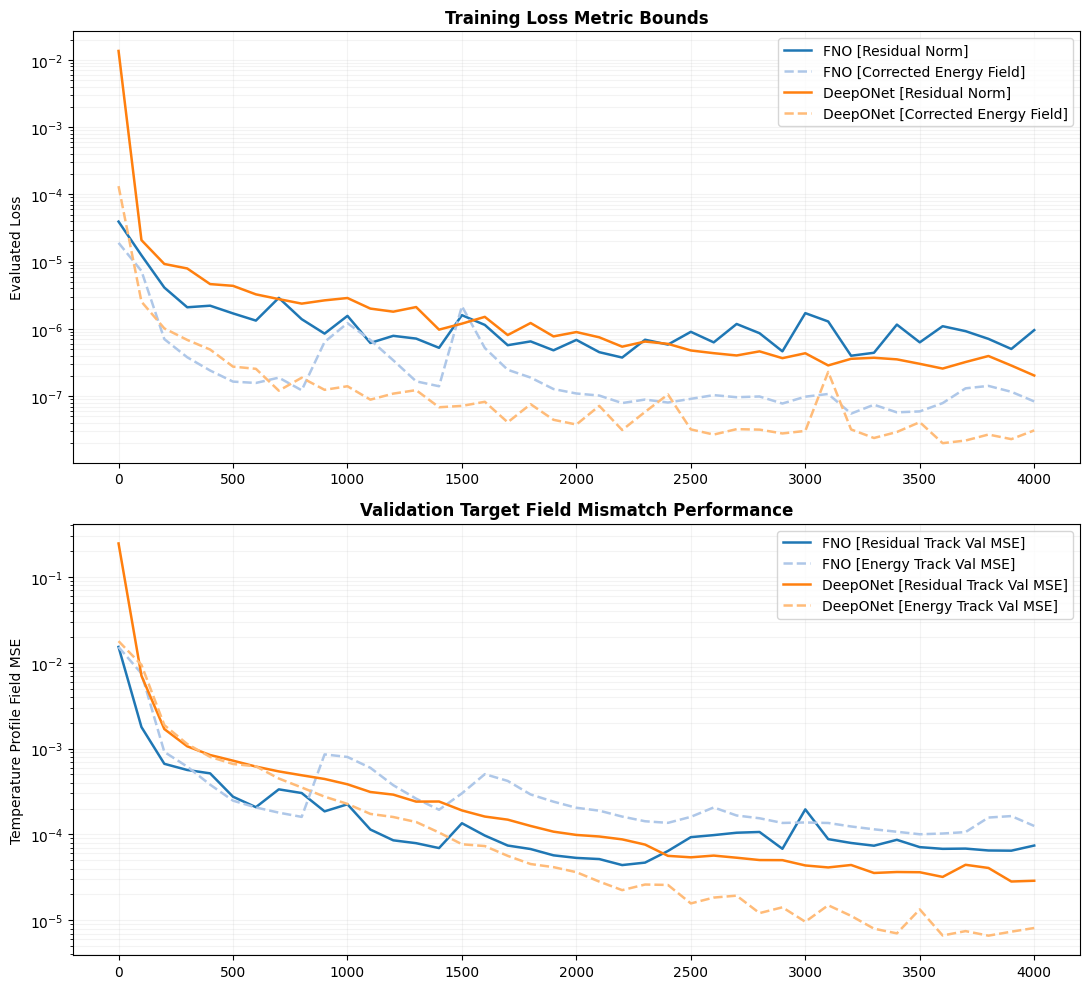

Generating tracking statistics for downstream plots...


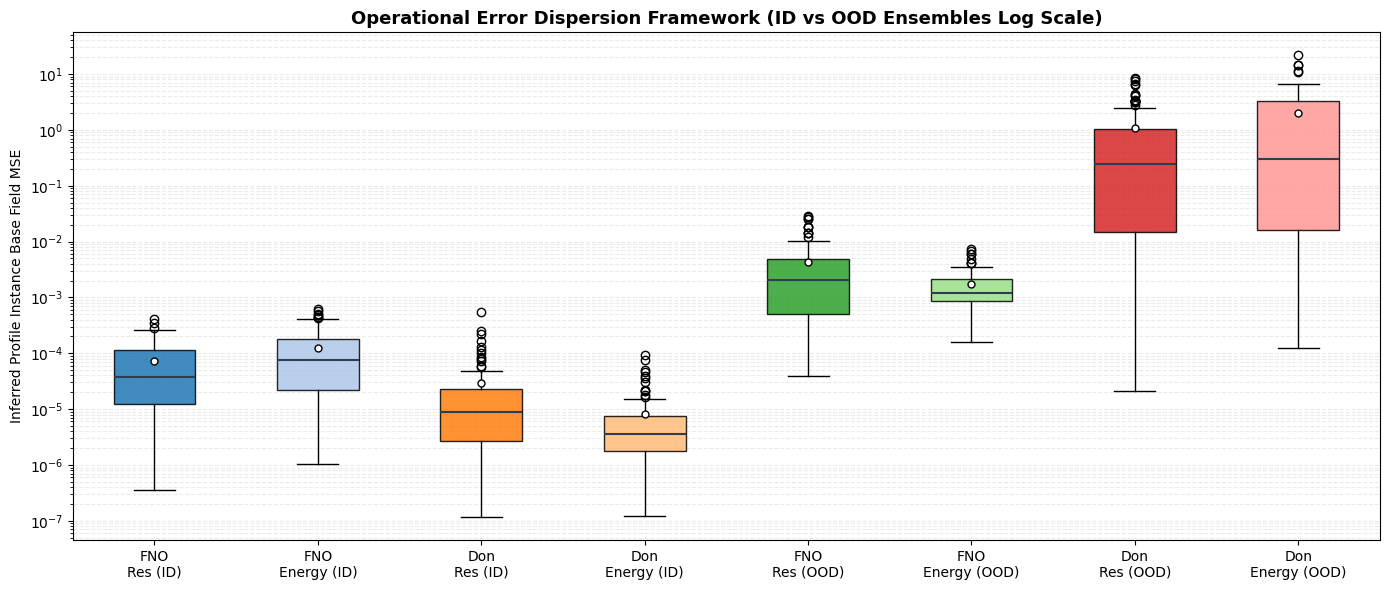

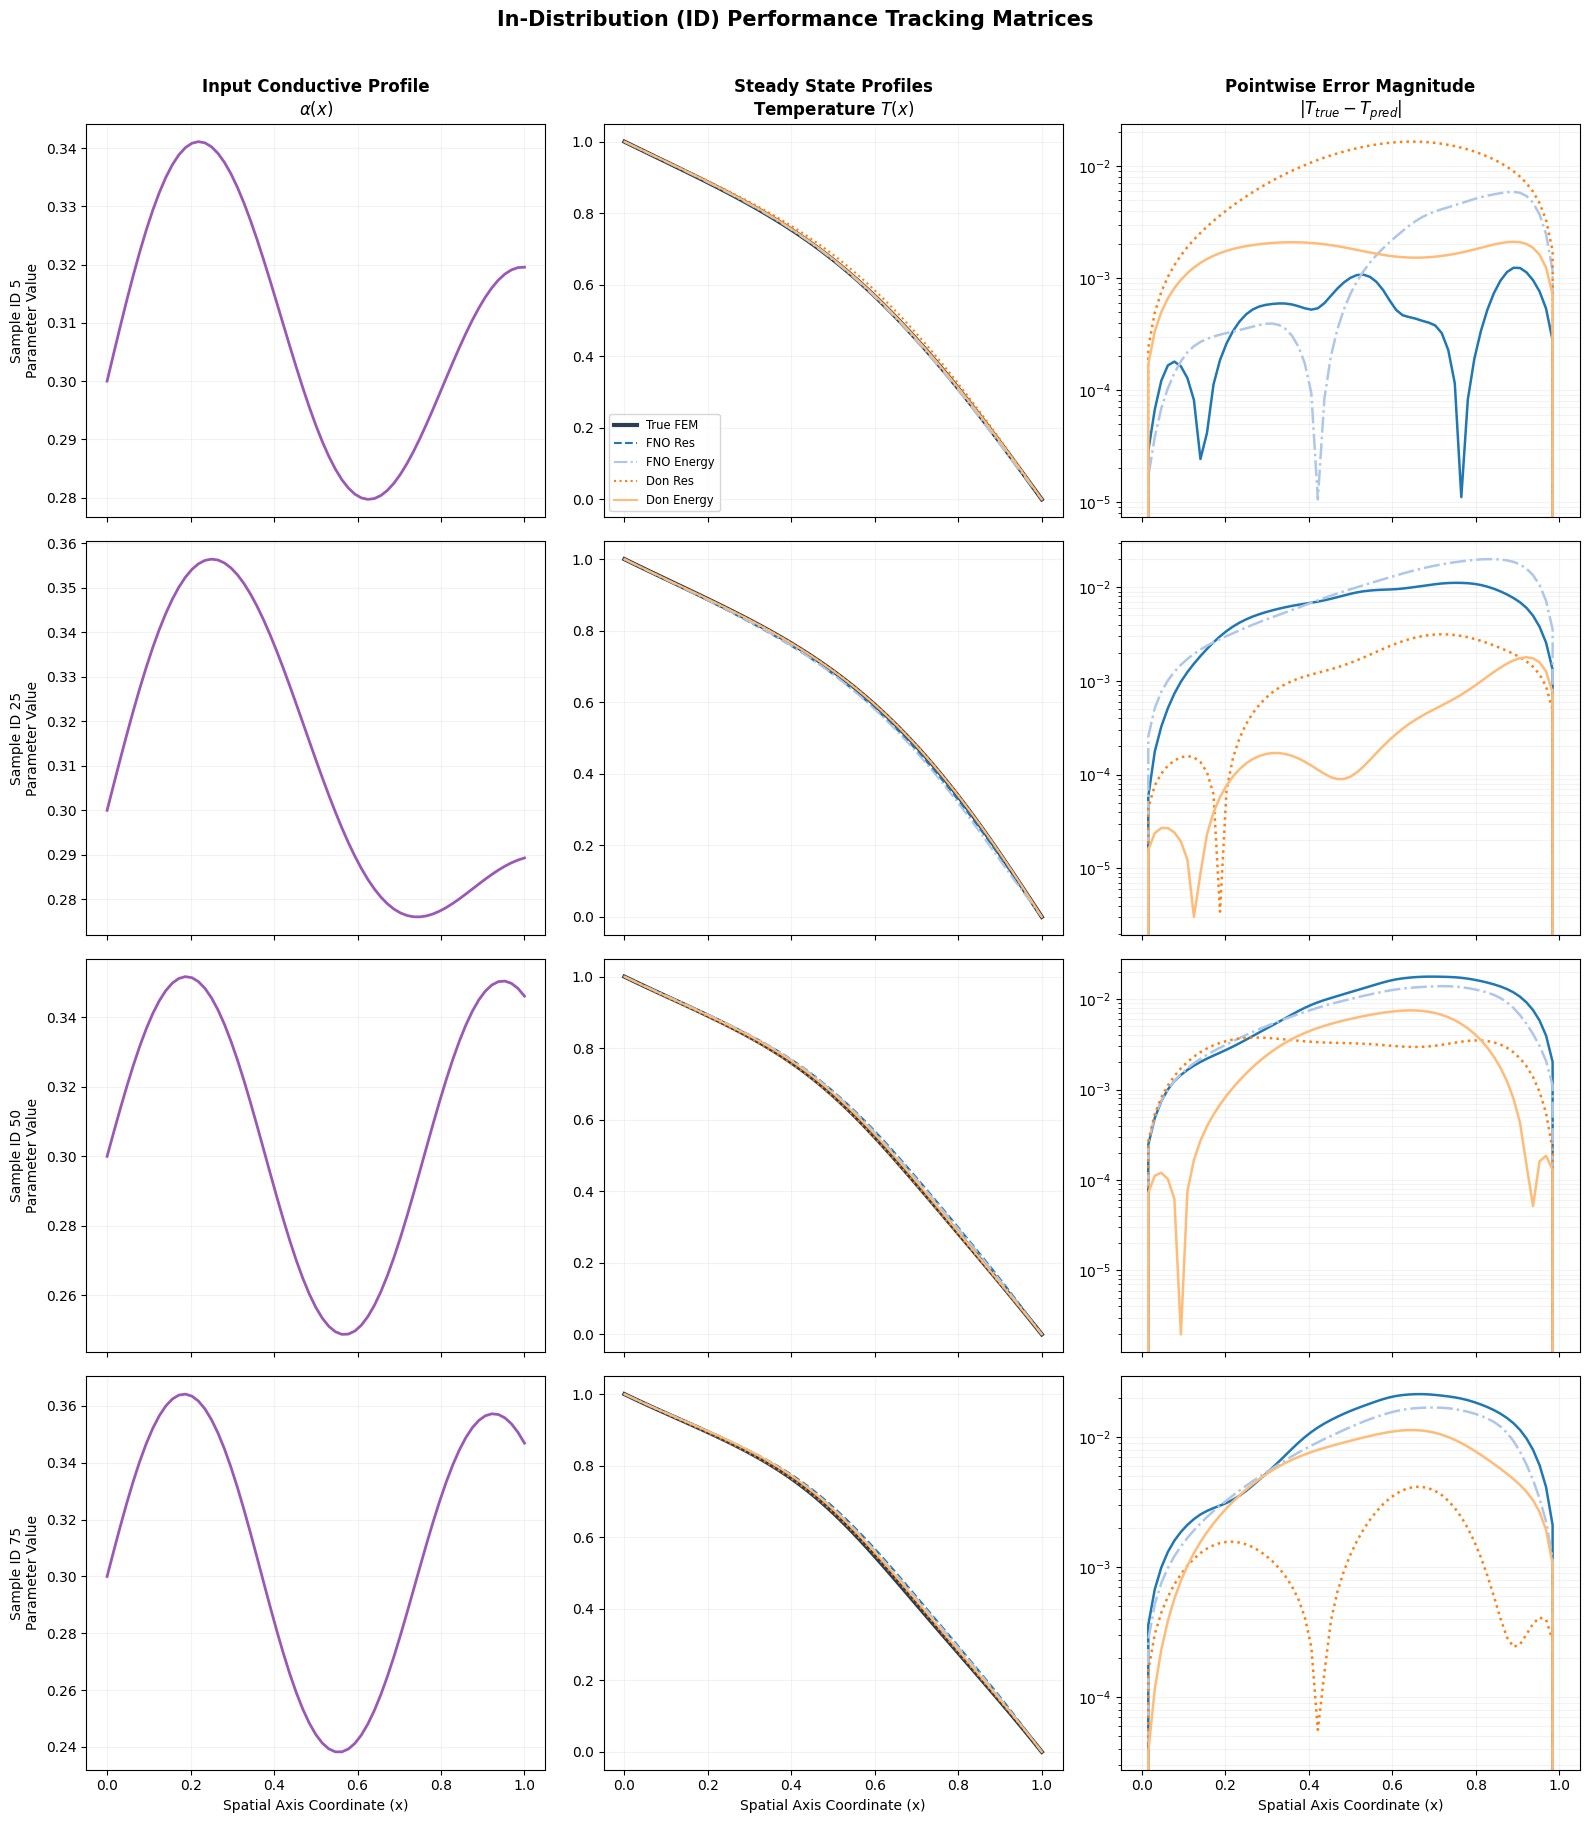

Rendering OOD Extrapolation Matrices (Step, Pyramid, Sharp-Sine)...


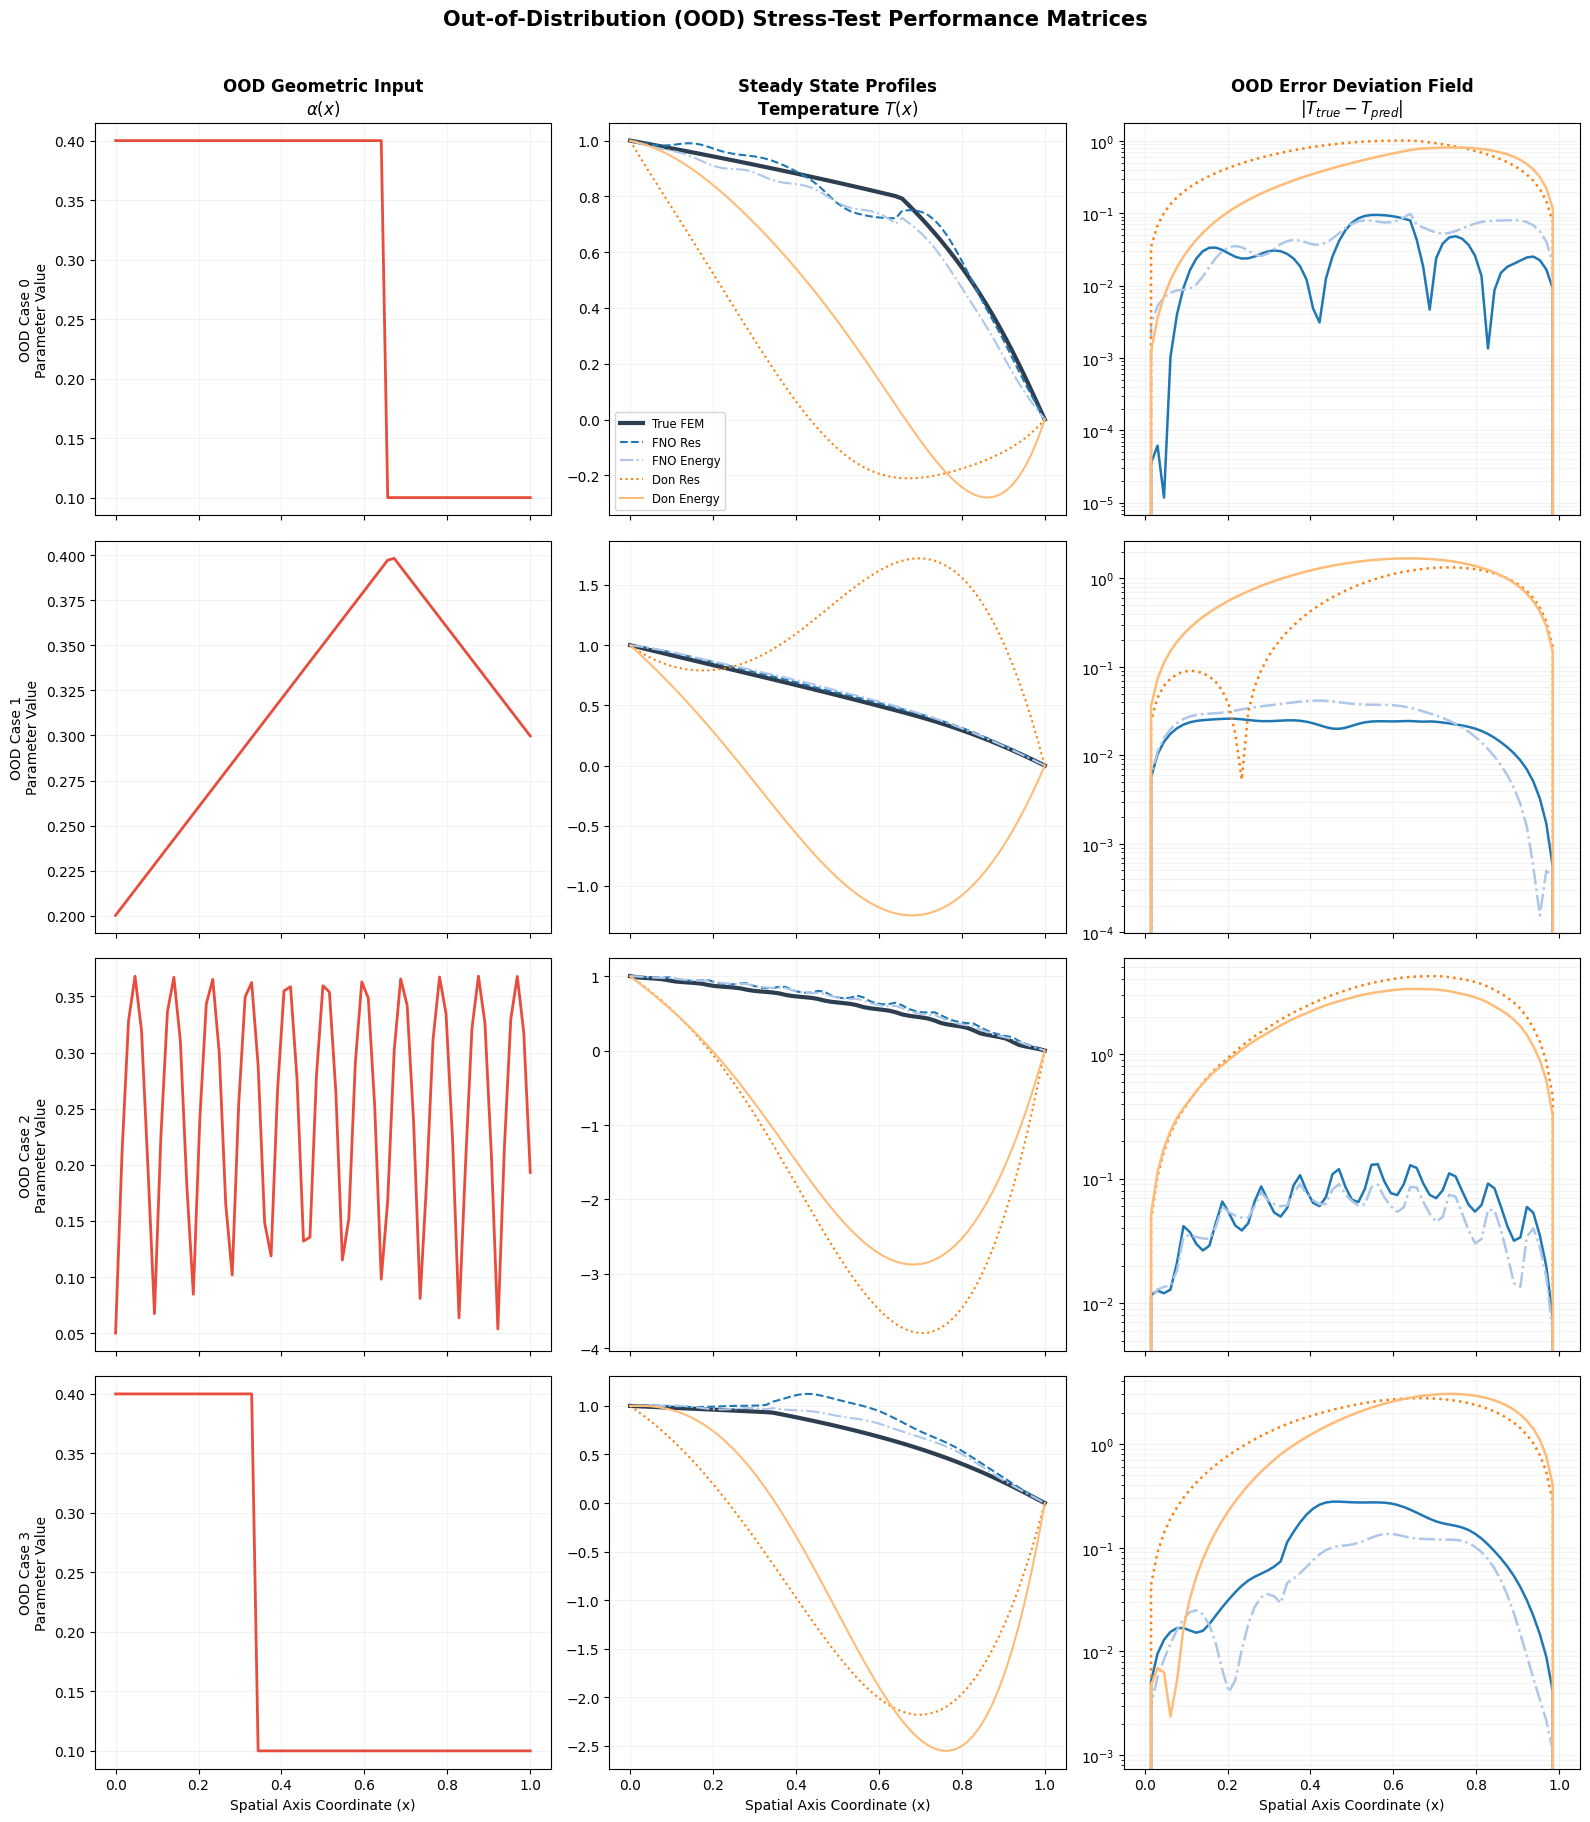

In [3]:
# ==========================================
# PLOT 1: LOSS AND TARGET CONVERGENCE FIELDS
# ==========================================
epochs_axis = np.arange(0, EPOCHS, 100)
plt.rcParams.update({'font.size': 10, 'lines.linewidth': 1.8})
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 10))

c_fno_r, c_fno_e = '#1f77b4', '#aec7e8'
c_don_r, c_don_e = '#ff7f0e', '#ffbb78'

ax0.plot(epochs_axis, fno_t_res, color=c_fno_r, label='FNO [Residual Norm]')
ax0.plot(epochs_axis, fno_t_eng, color=c_fno_e, ls='--', label='FNO [Corrected Energy Field]')
ax0.plot(epochs_axis, don_t_res, color=c_don_r, label='DeepONet [Residual Norm]')
ax0.plot(epochs_axis, don_t_eng, color=c_don_e, ls='--', label='DeepONet [Corrected Energy Field]')
ax0.set_yscale('log')
ax0.set_title("Training Loss Metric Bounds", fontweight='bold', fontsize=12)
ax0.set_ylabel("Evaluated Loss")
ax0.grid(True, which="both", alpha=0.15)
ax0.legend(loc='upper right')

ax1.plot(epochs_axis, fno_v_res, color=c_fno_r, label='FNO [Residual Track Val MSE]')
ax1.plot(epochs_axis, fno_v_eng, color=c_fno_e, ls='--', label='FNO [Energy Track Val MSE]')
ax1.plot(epochs_axis, don_v_res, color=c_don_r, label='DeepONet [Residual Track Val MSE]')
ax1.plot(epochs_axis, don_v_eng, color=c_don_e, ls='--', label='DeepONet [Energy Track Val MSE]')
ax1.set_yscale('log')
ax1.set_title("Validation Target Field Mismatch Performance", fontweight='bold', fontsize=12)
ax1.set_ylabel("Temperature Profile Field MSE")
ax1.grid(True, which="both", alpha=0.15)
ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: COMPREHENSIVE ERROR DISPERSION BOXPLOT
# ==========================================
print("Generating tracking statistics for downstream plots...")
all_fno_res_id = jax.vmap(fno_model, (None, 0))(fno_p_res, X_fno_val_norm)
all_fno_eng_id = jax.vmap(fno_model, (None, 0))(fno_p_eng, X_fno_val_norm)
all_don_res_id = jax.vmap(don_predict_field, (None, 0))(don_p_res, alpha_val_norm)
all_don_eng_id = jax.vmap(don_predict_field, (None, 0))(don_p_eng, alpha_val_norm)

all_fno_res_ood = jax.vmap(fno_model, (None, 0))(fno_p_res, X_fno_ood_norm)
all_fno_eng_ood = jax.vmap(fno_model, (None, 0))(fno_p_eng, X_fno_ood_norm)
all_don_res_ood = jax.vmap(don_predict_field, (None, 0))(don_p_res, alpha_ood_norm)
all_don_eng_ood = jax.vmap(don_predict_field, (None, 0))(don_p_eng, alpha_ood_norm)

err_fno_r_id = np.mean((all_fno_res_id - Y_val)**2, axis=1)
err_fno_e_id = np.mean((all_fno_eng_id - Y_val)**2, axis=1)
err_don_r_id = np.mean((all_don_res_id - Y_val)**2, axis=1)
err_don_e_id = np.mean((all_don_eng_id - Y_val)**2, axis=1)

err_fno_r_ood = np.mean((all_fno_res_ood - Y_val_ood)**2, axis=1)
err_fno_e_ood = np.mean((all_fno_eng_ood - Y_val_ood)**2, axis=1)
err_don_r_ood = np.mean((all_don_res_ood - Y_val_ood)**2, axis=1)
err_don_e_ood = np.mean((all_don_eng_ood - Y_val_ood)**2, axis=1)

boxplot_8_data = [
    err_fno_r_id, err_fno_e_id, err_don_r_id, err_don_e_id,
    err_fno_r_ood, err_fno_e_ood, err_don_r_ood, err_don_e_ood
]
labels_8 = [
    'FNO\nRes (ID)', 'FNO\nEnergy (ID)', 'Don\nRes (ID)', 'Don\nEnergy (ID)',
    'FNO\nRes (OOD)', 'FNO\nEnergy (OOD)', 'Don\nRes (OOD)', 'Don\nEnergy (OOD)'
]

fig, ax = plt.subplots(figsize=(14, 6))
# Updated 'labels' to 'tick_labels' to remove deprecation warning
box = ax.boxplot(boxplot_8_data, tick_labels=labels_8, patch_artist=True, showmeans=True,
                 medianprops={'color': '#2c3e50', 'linewidth': 1.5},
                 meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize': 5})

colors_8 = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728', '#ff9896']
for patch, color in zip(box['boxes'], colors_8):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_yscale('log')
ax.set_title("Operational Error Dispersion Framework (ID vs OOD Ensembles Log Scale)", fontweight='bold', fontsize=13)
ax.set_ylabel("Inferred Profile Instance Base Field MSE")
ax.grid(True, which="both", ls="--", alpha=0.25, axis='y')
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 3: 4 SEEN/IN-DISTRIBUTION PROFILE MATRICES
# ==========================================
seen_indices = [5, 25, 50, 75]
fig, axes = plt.subplots(4, 3, figsize=(16, 18), sharex='col')
c_ref, c_fr, c_fe, c_dr, c_de = '#2c3e50', '#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78'

for row, idx in enumerate(seen_indices):
    alpha_s = alpha_val[idx]
    true_s = Y_val[idx]
    fr_p = all_fno_res_id[idx]; fe_p = all_fno_eng_id[idx]
    dr_p = all_don_res_id[idx]; de_p = all_don_eng_id[idx]
    
    # Col 0: Input Conductivity Channel
    axes[row, 0].plot(GRID, alpha_s, color='#9b59b6', lw=2)
    axes[row, 0].set_ylabel(f"Sample ID {idx}\nParameter Value")
    axes[row, 0].grid(True, alpha=0.15)
    if row == 0: axes[row, 0].set_title("Input Conductive Profile\n$\\alpha(x)$", fontweight='bold')
    
    # Col 1: Core Physical Temperature Profiles
    axes[row, 1].plot(GRID, true_s, color=c_ref, lw=3, label='True FEM')
    axes[row, 1].plot(GRID, fr_p, color=c_fr, lw=1.5, ls='--', label='FNO Res')
    axes[row, 1].plot(GRID, fe_p, color=c_fe, lw=1.5, ls='-.', label='FNO Energy')
    axes[row, 1].plot(GRID, dr_p, color=c_dr, lw=1.5, ls=':', label='Don Res')
    axes[row, 1].plot(GRID, de_p, color=c_de, lw=1.5, ls='-', label='Don Energy')
    axes[row, 1].grid(True, alpha=0.15)
    if row == 0: 
        axes[row, 1].set_title("Steady State Profiles\nTemperature $T(x)$", fontweight='bold')
        axes[row, 1].legend(loc='lower left', fontsize='small')
        
    # Col 2: Pointwise Absolute Errors
    axes[row, 2].plot(GRID, jnp.abs(true_s - fr_p), color=c_fr)
    axes[row, 2].plot(GRID, jnp.abs(true_s - fe_p), color=c_fe, ls='-.')
    axes[row, 2].plot(GRID, jnp.abs(true_s - dr_p), color=c_dr, ls=':')
    axes[row, 2].plot(GRID, jnp.abs(true_s - de_p), color=c_de, ls='-')
    axes[row, 2].set_yscale('log')
    axes[row, 2].grid(True, which="both", alpha=0.15)
    if row == 0: axes[row, 2].set_title("Pointwise Error Magnitude\n$|T_{true} - T_{pred}|$", fontweight='bold')

for ax in axes[-1, :]: ax.set_xlabel("Spatial Axis Coordinate (x)")
plt.suptitle("In-Distribution (ID) Performance Tracking Matrices", fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 4: 4 UNSEEN/OOD STRESS TEST MATRICES
# ==========================================
print("Rendering OOD Extrapolation Matrices (Step, Pyramid, Sharp-Sine)...")
ood_indices = [0, 1, 2, 3] 
fig, axes = plt.subplots(4, 3, figsize=(16, 18), sharex='col')

for row, idx in enumerate(ood_indices):
    alpha_o = alpha_ood[idx]
    true_o = Y_val_ood[idx]
    fr_p = all_fno_res_ood[idx]; fe_p = all_fno_eng_ood[idx]
    dr_p = all_don_res_ood[idx]; de_p = all_don_eng_ood[idx]
    
    # Col 0: Sharp Geometry Structural Modifiers
    axes[row, 0].plot(GRID, alpha_o, color='#e74c3c', lw=2)
    axes[row, 0].set_ylabel(f"OOD Case {idx}\nParameter Value")
    axes[row, 0].grid(True, alpha=0.15)
    if row == 0: axes[row, 0].set_title("OOD Geometric Input\n$\\alpha(x)$", fontweight='bold')
    
    # Col 1: Solution Mapping Profile Tracks
    axes[row, 1].plot(GRID, true_o, color=c_ref, lw=3, label='True FEM')
    axes[row, 1].plot(GRID, fr_p, color=c_fr, lw=1.5, ls='--', label='FNO Res')
    axes[row, 1].plot(GRID, fe_p, color=c_fe, lw=1.5, ls='-.', label='FNO Energy')
    axes[row, 1].plot(GRID, dr_p, color=c_dr, lw=1.5, ls=':', label='Don Res')
    axes[row, 1].plot(GRID, de_p, color=c_de, lw=1.5, ls='-', label='Don Energy')
    axes[row, 1].grid(True, alpha=0.15)
    if row == 0: 
        axes[row, 1].set_title("Steady State Profiles\nTemperature $T(x)$", fontweight='bold')
        axes[row, 1].legend(loc='lower left', fontsize='small')
        
    # Col 2: High-Frequency Local Pointwise Absolute Error Fields
    axes[row, 2].plot(GRID, jnp.abs(true_o - fr_p), color=c_fr)
    axes[row, 2].plot(GRID, jnp.abs(true_o - fe_p), color=c_fe, ls='-.')
    axes[row, 2].plot(GRID, jnp.abs(true_o - dr_p), color=c_dr, ls=':')
    axes[row, 2].plot(GRID, jnp.abs(true_o - de_p), color=c_de, ls='-')
    axes[row, 2].set_yscale('log')
    axes[row, 2].grid(True, which="both", alpha=0.15)
    if row == 0: axes[row, 2].set_title("OOD Error Deviation Field\n$|T_{true} - T_{pred}|$", fontweight='bold')

for ax in axes[-1, :]: ax.set_xlabel("Spatial Axis Coordinate (x)")
plt.suptitle("Out-of-Distribution (OOD) Stress-Test Performance Matrices", fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()